# 03 — Inventory Simulation

Turns the Prophet forecast (with uncertainty) from notebook 02 into a **lead-time demand distribution** via Monte Carlo simulation, then derives safety stock for a target service level. See `src/inventory_sim.py` for the mechanics and the documented independence assumption.

**Business assumptions (would come from procurement/ops in a real deployment — stated explicitly here since this is a portfolio recreation):**
- Supplier lead time: 7 days
- Target service level: 95% (i.e., stock out in at most 1 of 20 replenishment cycles)

Both are easy to swap — the point of the notebook is the *method*, not these specific numbers.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import pandas as pd

from src.data_loader import save_processed
from src.inventory_sim import service_level_curve, simulate_for_series, add_implied_sigma, simulate_lead_time_demand

LEAD_TIME_DAYS = 7
TARGET_SERVICE_LEVEL = 0.95

forecast_table = pd.read_parquet(Path.cwd().parent / "data" / "processed" / "forecast_all_series.parquet")
# Rows with actual == NaN are the forward-looking forecast horizon from notebook 02 (post-history).
future_forecast = forecast_table[forecast_table["actual"].isna()].sort_values("ds")
future_forecast.head()

,ds,yhat,yhat_lower,yhat_upper,store,item,actual
1826,2018-01-01,13.593169,7.978103,19.532294,1,1,NaN
703082,2018-01-01,24.827967,16.549298,33.000734,8,17,NaN
86130,2018-01-01,46.714150,35.209807,57.518170,1,45,NaN
701166,2018-01-01,21.577256,14.757494,28.633367,8,16,NaN
699250,2018-01-01,72.295302,59.035039,85.767270,8,15,NaN


## Worked example: one SKU

Walk through the mechanics for store=1/item=1 before scaling to all 500 series.

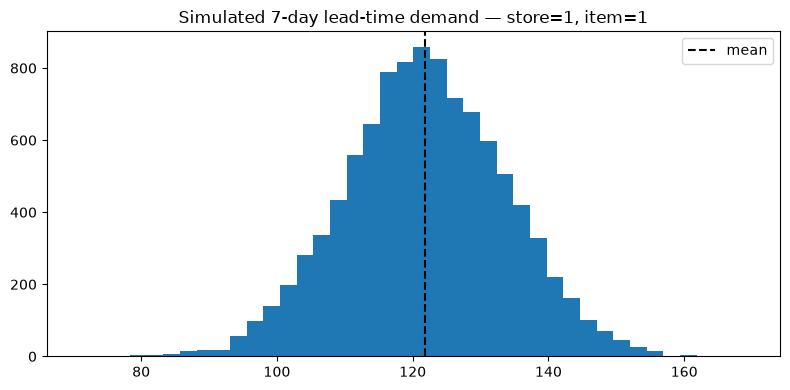

In [2]:
example = future_forecast[(future_forecast["store"] == 1) & (future_forecast["item"] == 1)]
example_sigma = add_implied_sigma(example)
samples = simulate_lead_time_demand(example_sigma, LEAD_TIME_DAYS, n_sims=10_000)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(samples, bins=40)
ax.set_title(f"Simulated {LEAD_TIME_DAYS}-day lead-time demand — store=1, item=1")
ax.axvline(samples.mean(), color="black", linestyle="--", label="mean")
ax.legend()
plt.tight_layout()

## Service level vs. safety stock tradeoff

The chart that makes the business tradeoff concrete: higher service level (fewer stockouts) costs more safety stock (more holding cost). This is exactly the chart that belongs on the Power BI "Inventory Risk" page, parameterized by a service-level slider.

,service_level,safety_stock
0,0.800,10.036214
1,0.850,12.424917
2,0.900,15.264123
3,0.950,19.490245
4,0.975,23.088935
5,0.990,27.507593


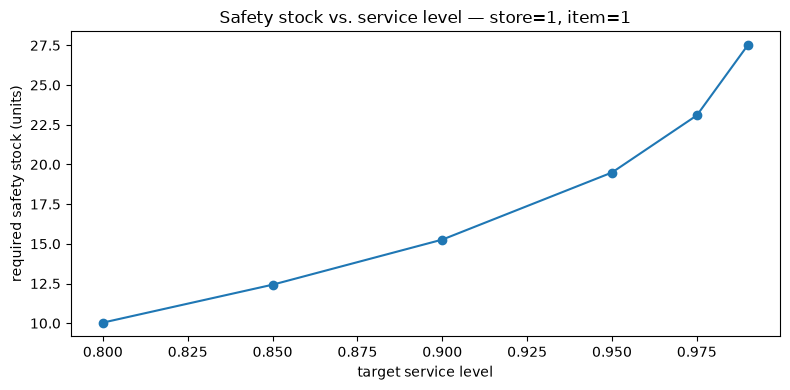

In [3]:
curve = service_level_curve(samples)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(curve["service_level"], curve["safety_stock"], marker="o")
ax.set_xlabel("target service level"); ax.set_ylabel("required safety stock (units)")
ax.set_title("Safety stock vs. service level — store=1, item=1")
plt.tight_layout()
curve

## Scale to all 500 series

In [4]:
sim_rows = []
for (store, item), group in future_forecast.groupby(["store", "item"]):
    result = simulate_for_series(
        group.sort_values("ds"), store, item, LEAD_TIME_DAYS, TARGET_SERVICE_LEVEL
    )
    sim_rows.append(result)

sim_results = pd.DataFrame(sim_rows)
print(sim_results.shape)
save_processed(sim_results, "inventory_simulation")
sim_results.to_csv(Path.cwd().parent / "outputs" / "inventory_simulation.csv", index=False)
sim_results.sort_values("safety_stock", ascending=False).head(10)

(500, 7)


,store,item,lead_time_days,target_service_level,expected_lead_time_demand,safety_stock,p95_lead_time_demand
64,2,15,7,0.95,689.660625,51.472670,741.133295
77,2,28,7,0.95,678.267998,49.901027,728.169025
67,2,18,7,0.95,661.119756,49.766564,710.886319
62,2,13,7,0.95,649.758184,49.024452,698.782635
94,2,45,7,0.95,636.115631,48.946519,685.062151
377,8,28,7,0.95,663.031500,48.723974,711.755473
87,2,38,7,0.95,636.932830,48.325871,685.258700
367,8,18,7,0.95,632.611167,48.302811,680.913978
364,8,15,7,0.95,667.347772,47.914950,715.262723
477,10,28,7,0.95,601.194403,47.739988,648.934391


## Safety-stock curve for every SKU, across service levels

The single-SKU chart above is illustrative, but the Power BI "Inventory Risk" page should let someone pick a service level and see safety stock update for *any* SKU — that needs this precomputed per-series, per-service-level table (Power BI has no live Python/Monte Carlo engine, so the tradeoff curve has to be exported, not computed on the fly).

In [5]:
curve_rows = []
for (store, item), group in future_forecast.groupby(["store", "item"]):
    group_sigma = add_implied_sigma(group.sort_values("ds"))
    series_samples = simulate_lead_time_demand(group_sigma, LEAD_TIME_DAYS, n_sims=5_000)
    series_curve = service_level_curve(series_samples)
    series_curve["store"] = store
    series_curve["item"] = item
    curve_rows.append(series_curve)

safety_stock_curve = pd.concat(curve_rows, ignore_index=True)
print(safety_stock_curve.shape)
safety_stock_curve.to_csv(Path.cwd().parent / "outputs" / "safety_stock_curve.csv", index=False)

(3000, 4)


## Sanity check

Safety stock should broadly track the demand-variability (CV) table from notebook 01 — high-CV SKUs should need proportionally more safety stock. Worth a quick scatter to confirm the pipeline is behaving sensibly before trusting it for reorder logic in notebook 04.

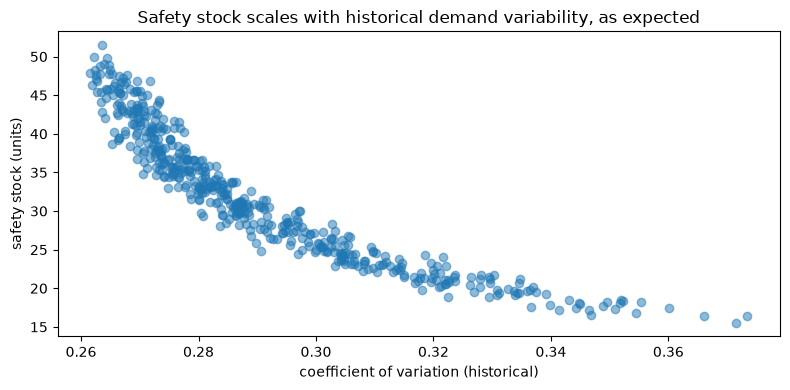

In [6]:
variability = pd.read_parquet(Path.cwd().parent / "data" / "processed" / "series_variability.parquet")
check = sim_results.merge(variability, on=["store", "item"])

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(check["cv"], check["safety_stock"], alpha=0.5)
ax.set_xlabel("coefficient of variation (historical)"); ax.set_ylabel("safety stock (units)")
ax.set_title("Safety stock scales with historical demand variability, as expected")
plt.tight_layout()